# Report 2 — Member Churn Risk & Retention Analysis Dashboard

**Data sources** (generated by `r2export.sql`):
- `churn_risk_summary.csv` : roll-up by cohort / type / status / risk tier
- `churn_risk_members.csv` : member-level RFM detail

**Charts produced (6):**
1. Stacked bar — Revenue at Risk vs Safe Revenue by Risk Tier
2. Horizontal bar — Probability-Weighted Revenue at Risk by Cohort Year
3. Heatmap — Member Count by Cohort Year × Risk Tier
4. Scatter — Churn Score vs Total Revenue, coloured by Risk Tier
5. Grouped bar — VIP vs NORMAL member count across Risk Tiers
6. 100% Stacked bar — Revenue share by Risk Tier per Cohort Year

In [5]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")
matplotlib.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "figure.dpi": 130,
})

HERE = os.path.dirname(os.path.abspath("__file__"))
# If running in Jupyter, use current working directory instead:
# HERE = os.getcwd()

## Load Data

Ensure `churn_risk_summary.csv` and `churn_risk_members.csv` are in the same directory as this notebook.

In [6]:
SUM_CSV = os.path.join(HERE, "churn_risk_summary.csv")
MEM_CSV = os.path.join(HERE, "churn_risk_members.csv")

SUM_COLS = [
    "cohort_year", "member_type", "member_status", "risk_tier",
    "member_count", "avg_recency_days", "total_orders",
    "total_revenue", "revenue_at_risk", "avg_churn_score",
]
MEM_COLS = [
    "member_id", "member_type", "member_status", "cohort_year",
    "registration_date", "last_order_date", "recency_days",
    "total_orders", "total_revenue", "avg_order_value",
    "risk_tier", "churn_score",
]

df  = pd.read_csv(SUM_CSV, header=0, names=SUM_COLS)
dfm = pd.read_csv(MEM_CSV, header=0, names=MEM_COLS)

# Coerce numerics
for col in ["member_count", "avg_recency_days", "total_orders",
            "total_revenue", "revenue_at_risk", "avg_churn_score"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["recency_days", "total_orders", "total_revenue",
            "avg_order_value", "churn_score"]:
    dfm[col] = pd.to_numeric(dfm[col], errors="coerce")

print(f"Summary rows: {len(df)}")
print(f"Member rows:  {len(dfm)}")

Summary rows: 49
Member rows:  100


## Colour Palettes & Constants

In [7]:
TIER_ORDER  = ["Churned", "Critical", "High", "Suspended",
               "Medium", "Low", "Healthy", "New - No Order"]

TIER_COLORS = {
    "Churned":       "#C0392B",
    "Critical":      "#E74C3C",
    "High":          "#E67E22",
    "Suspended":     "#9B59B6",
    "Medium":        "#F1C40F",
    "Low":           "#3498DB",
    "Healthy":       "#2ECC71",
    "New - No Order":"#95A5A6",
}

TYPE_COLORS = {"VIP": "#F5A623", "NORMAL": "#4C9BE8"}

# Prepare figure grid
fig = plt.figure(figsize=(24, 28))
fig.suptitle(
    "Report 2 — Member Churn Risk & Retention Analysis Dashboard",
    fontsize=18, fontweight="bold", y=0.995
)
gs = fig.add_gridspec(3, 2, hspace=0.46, wspace=0.35)

<Figure size 3120x3640 with 0 Axes>

## Viz 1 — Safe vs At-Risk Revenue by Risk Tier

Shows the split between revenue already lost / at-risk and safe revenue.

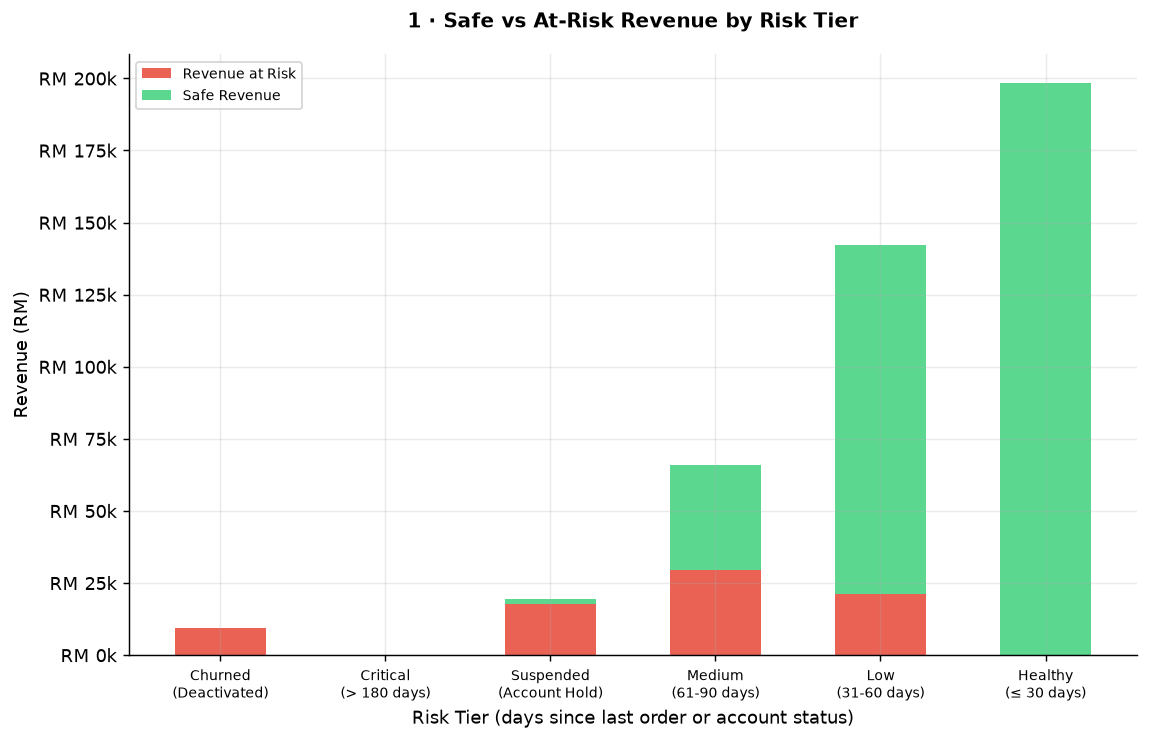

In [10]:
fig, ax1 = plt.subplots(figsize=(10, 6))
grp1 = df.groupby("risk_tier")[["total_revenue", "revenue_at_risk"]].sum()
grp1["safe_revenue"] = grp1["total_revenue"] - grp1["revenue_at_risk"]
grp1 = grp1.reindex([t for t in TIER_ORDER if t in grp1.index])

x1 = np.arange(len(grp1))
w1 = 0.55
bars_at = ax1.bar(x1, grp1["revenue_at_risk"], w1,
                  label="Revenue at Risk", color="#E74C3C", alpha=0.88)
bars_safe = ax1.bar(x1, grp1["safe_revenue"], w1,
                    bottom=grp1["revenue_at_risk"],
                    label="Safe Revenue", color="#2ECC71", alpha=0.78)

# Map labels to include recency periods
TIER_LABELS = {
    "Churned": "Churned\n(Deactivated)",
    "Critical": "Critical\n(> 180 days)",
    "High": "High\n(91-180 days)",
    "Suspended": "Suspended\n(Account Hold)",
    "Medium": "Medium\n(61-90 days)",
    "Low": "Low\n(31-60 days)",
    "Healthy": "Healthy\n(≤ 30 days)",
    "New - No Order": "New\n(≤ 30 days)"
}
new_labels = [TIER_LABELS.get(t, t) for t in grp1.index]

ax1.set_xticks(x1)
ax1.set_xticklabels(new_labels, rotation=0, ha="center", fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"RM {v/1000:.0f}k"))
ax1.set_title("1 · Safe vs At-Risk Revenue by Risk Tier", fontsize=11, pad=15)
ax1.set_ylabel("Revenue (RM)")
ax1.set_xlabel("Risk Tier (days since last order or account status)")
ax1.legend(fontsize=8)
plt.show()


## Viz 2 — Expected Revenue at Risk by Cohort Year

Gives executives the total expected financial exposure per cohort.

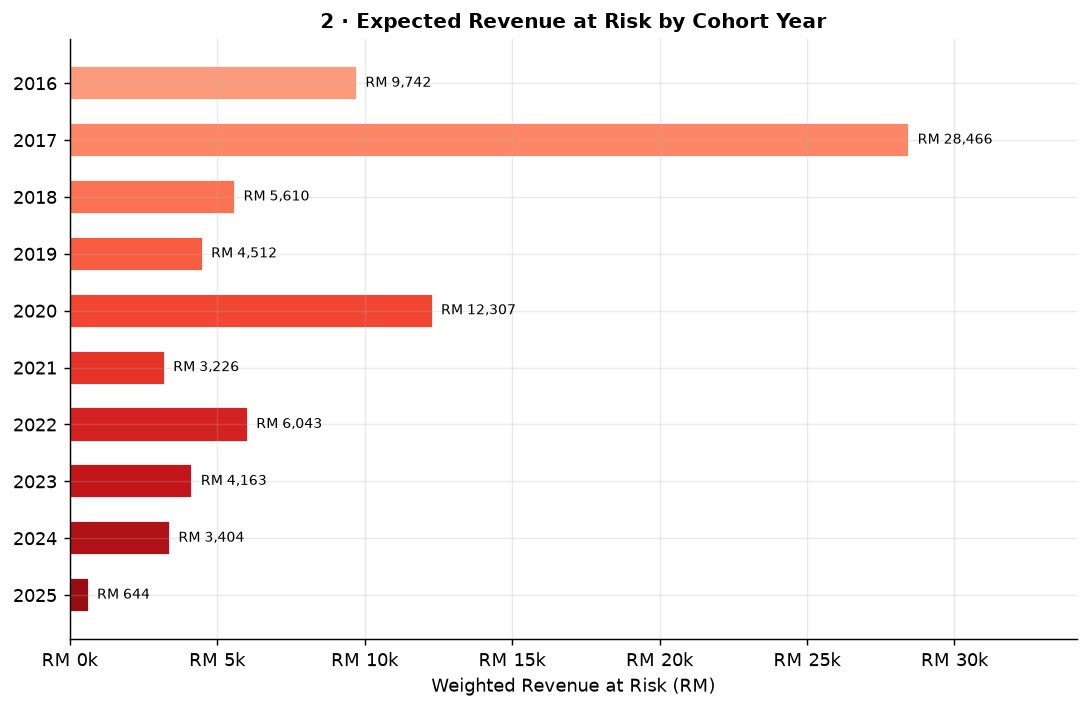

In [11]:
fig, ax2 = plt.subplots(figsize=(10, 6))
grp2 = df.groupby("cohort_year")["revenue_at_risk"].sum().sort_index()
colors2 = plt.cm.Reds(np.linspace(0.35, 0.90, len(grp2)))
bars2 = ax2.barh(grp2.index.astype(str), grp2.values,
                 color=colors2, edgecolor="white", height=0.6)

for bar, val in zip(bars2, grp2.values):
    ax2.text(val + grp2.max() * 0.01, bar.get_y() + bar.get_height() / 2,
             f"RM {val:,.0f}", va="center", fontsize=7.5)

ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"RM {v/1000:.0f}k"))
ax2.set_title("2 · Expected Revenue at Risk by Cohort Year")
ax2.set_xlabel("Weighted Revenue at Risk (RM)")
ax2.set_xlim(0, grp2.max() * 1.20)
ax2.invert_yaxis()
plt.show()

## Viz 3 — Member Count Heatmap: Cohort Year × Risk Tier

Highlights which cohorts have the most members in critical tiers.

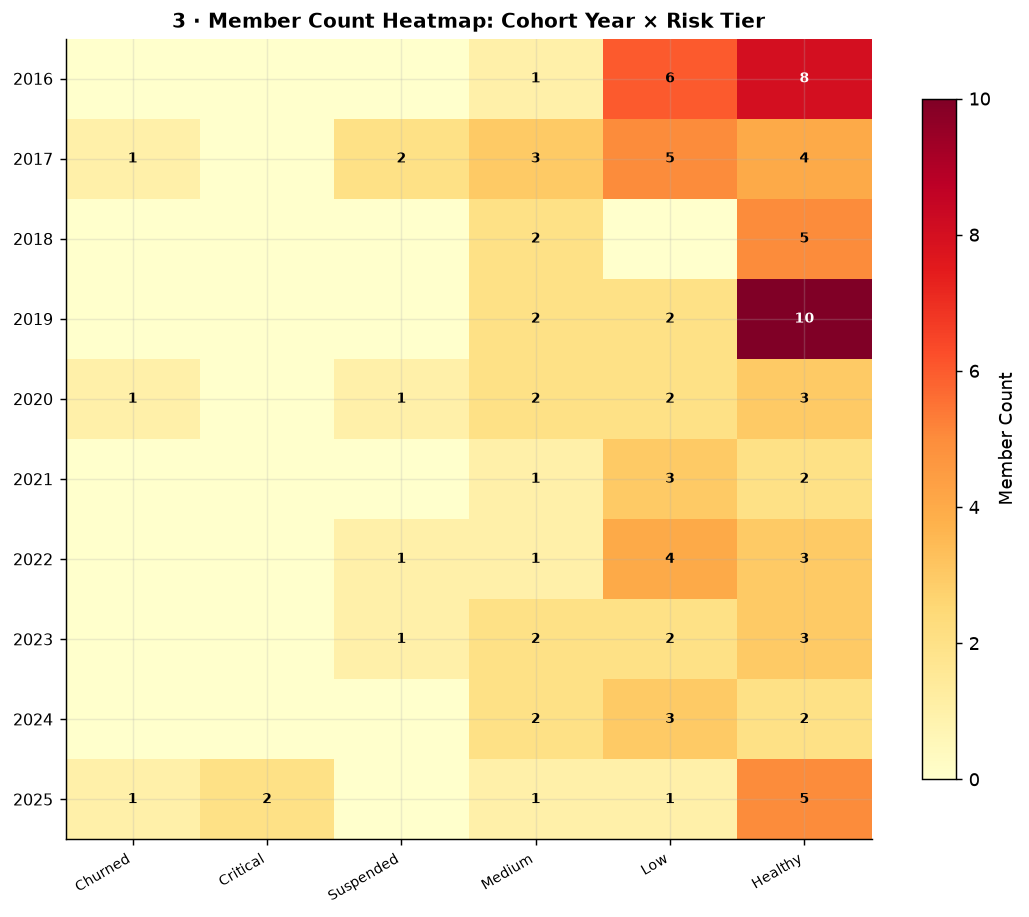

In [12]:
fig, ax3 = plt.subplots(figsize=(10, 8))
pivot3 = df.pivot_table(
    index="cohort_year", columns="risk_tier",
    values="member_count", aggfunc="sum", fill_value=0
)
pivot3 = pivot3.reindex(columns=[t for t in TIER_ORDER if t in pivot3.columns])

im = ax3.imshow(pivot3.values, cmap="YlOrRd", aspect="auto")
ax3.set_xticks(range(len(pivot3.columns)))
ax3.set_xticklabels(pivot3.columns, rotation=30, ha="right", fontsize=8)
ax3.set_yticks(range(len(pivot3.index)))
ax3.set_yticklabels(pivot3.index.astype(str), fontsize=9)

for row in range(len(pivot3.index)):
    for col in range(len(pivot3.columns)):
        val = int(pivot3.values[row, col])
        if val > 0:
            ax3.text(col, row, str(val),
                     ha="center", va="center",
                     fontsize=8, fontweight="bold",
                     color="white" if pivot3.values[row, col] > pivot3.values.max() * 0.6 else "black")

plt.colorbar(im, ax=ax3, label="Member Count", shrink=0.85)
ax3.set_title("3 · Member Count Heatmap: Cohort Year × Risk Tier")
plt.show()

## Viz 4 — Churn Score vs Revenue: Win-Back Target Quadrant

Identifies high-value members who are also high-risk — prime win-back targets.

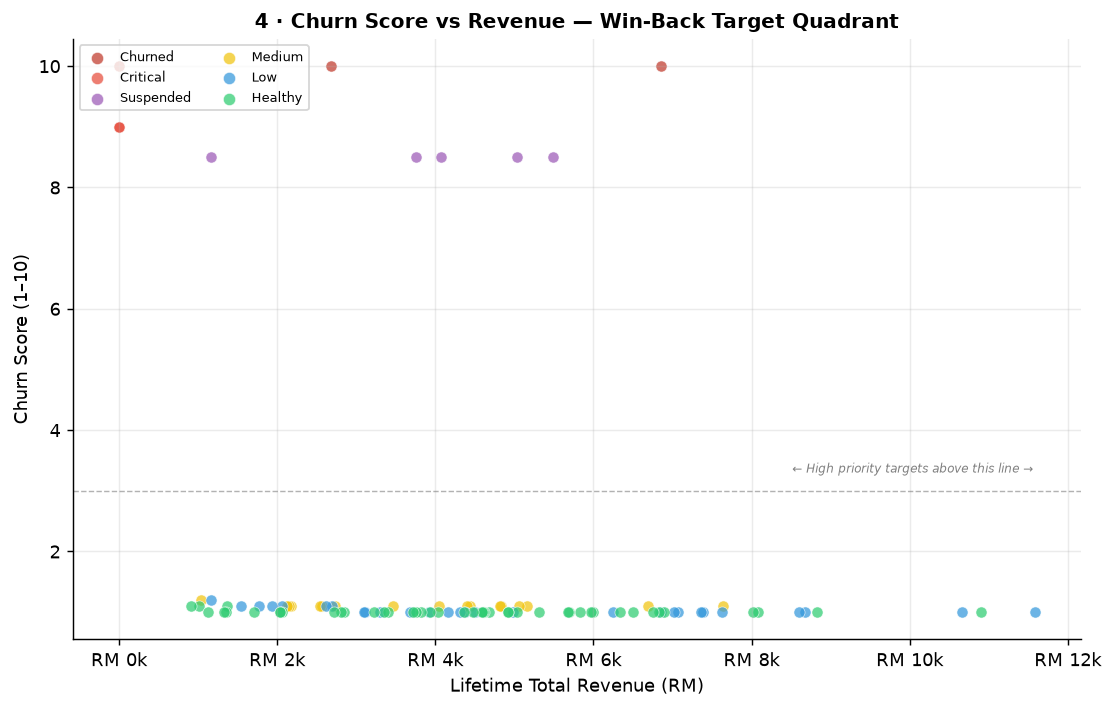

In [13]:
fig, ax4 = plt.subplots(figsize=(10, 6))
for tier in TIER_ORDER:
    sub = dfm[dfm["risk_tier"] == tier]
    if sub.empty:
        continue
    ax4.scatter(
        sub["total_revenue"], sub["churn_score"],
        c=TIER_COLORS.get(tier, "grey"),
        label=tier, alpha=0.72, s=38, edgecolors="white", linewidths=0.4
    )

ax4.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"RM {v/1000:.0f}k"))
ax4.set_xlabel("Lifetime Total Revenue (RM)")
ax4.set_ylabel("Churn Score (1–10)")
ax4.set_title("4 · Churn Score vs Revenue — Win-Back Target Quadrant")

ax4.axhline(y=3.0, color="grey", lw=0.8, ls="--", alpha=0.6)
ax4.text(ax4.get_xlim()[1] * 0.7, 3.3,
         "← High priority targets above this line →",
         fontsize=6.5, color="grey", style="italic")
ax4.legend(fontsize=7, markerscale=1.1, ncol=2, loc="upper left")
plt.show()

## Viz 5 — VIP vs NORMAL Member Count by Risk Tier

Checks whether VIP members are also concentrated in high-risk tiers.

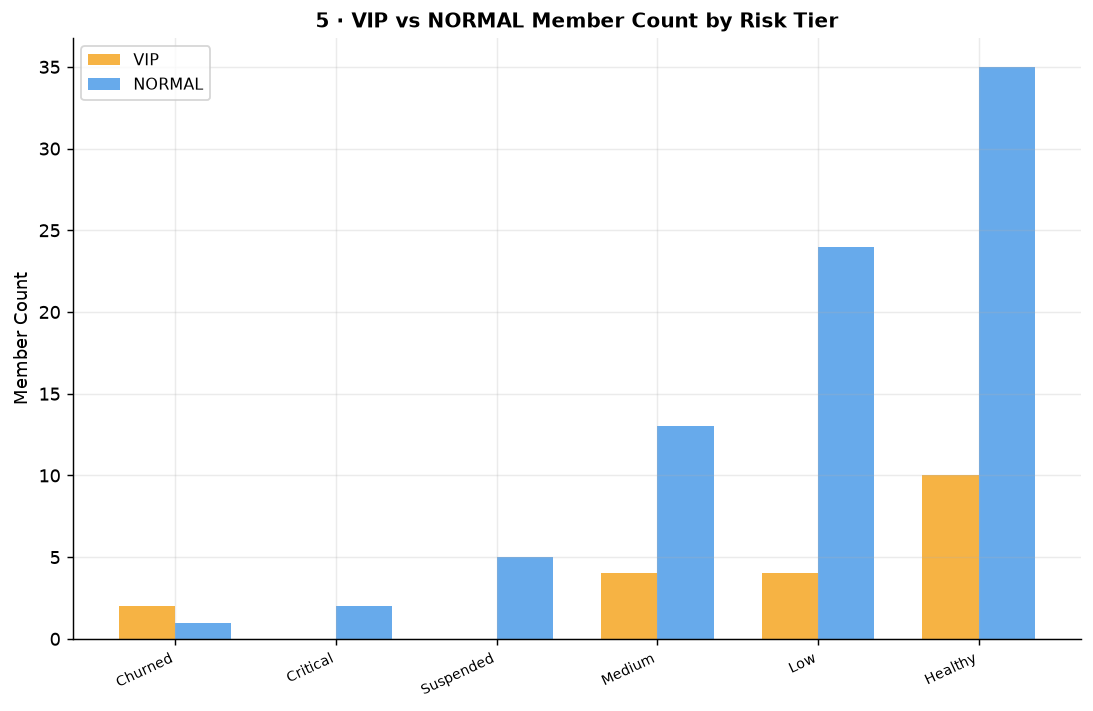

In [14]:
fig, ax5 = plt.subplots(figsize=(10, 6))
grp5 = df.groupby(["risk_tier", "member_type"])["member_count"].sum().unstack(fill_value=0)
grp5 = grp5.reindex([t for t in TIER_ORDER if t in grp5.index])
x5 = np.arange(len(grp5))
w5 = 0.35

for i, mtype in enumerate(["VIP", "NORMAL"]):
    if mtype in grp5.columns:
        ax5.bar(x5 + i * w5, grp5[mtype], w5,
                label=mtype, color=TYPE_COLORS[mtype], alpha=0.85)

ax5.set_xticks(x5 + w5 / 2)
ax5.set_xticklabels(grp5.index, rotation=25, ha="right", fontsize=8)
ax5.set_ylabel("Member Count")
ax5.set_title("5 · VIP vs NORMAL Member Count by Risk Tier")
ax5.legend(fontsize=9)
plt.show()

## Viz 6 — Revenue Share by Risk Tier per Cohort Year (100% Stacked)

Shows what % of each cohort's revenue sits in each risk tier.

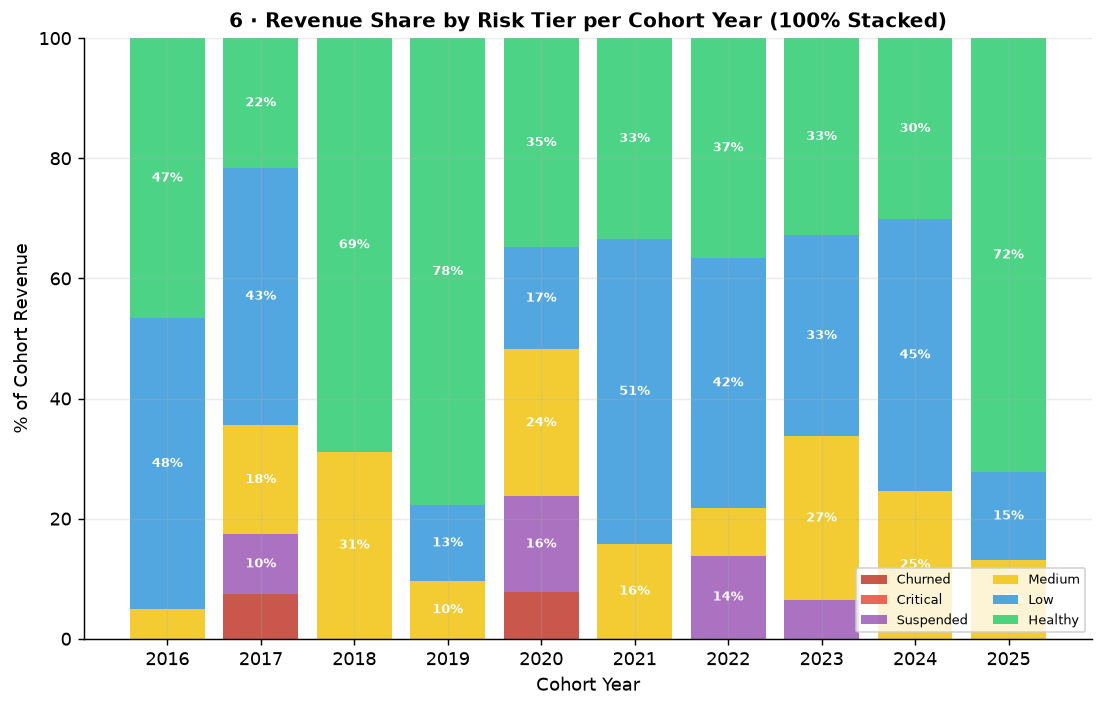

In [15]:
fig, ax6 = plt.subplots(figsize=(10, 6))
pivot6 = df.pivot_table(
    index="cohort_year", columns="risk_tier",
    values="total_revenue", aggfunc="sum", fill_value=0
)
pivot6 = pivot6.reindex(columns=[t for t in TIER_ORDER if t in pivot6.columns])
pivot6_pct = pivot6.div(pivot6.sum(axis=1), axis=0) * 100

bottom = np.zeros(len(pivot6_pct))
for tier in pivot6_pct.columns:
    vals = pivot6_pct[tier].values
    ax6.bar(pivot6_pct.index.astype(str), vals, bottom=bottom,
            label=tier, color=TIER_COLORS.get(tier, "grey"), alpha=0.85)
    for j, (v, b) in enumerate(zip(vals, bottom)):
        if v > 8:
            ax6.text(j, b + v / 2, f"{v:.0f}%",
                     ha="center", va="center", fontsize=7, fontweight="bold",
                     color="white")
    bottom += vals

ax6.set_ylim(0, 100)
ax6.set_ylabel("% of Cohort Revenue")
ax6.set_xlabel("Cohort Year")
ax6.set_title("6 · Revenue Share by Risk Tier per Cohort Year (100% Stacked)")
ax6.legend(fontsize=7, loc="lower right", ncol=2)
plt.show()